## Using Linear Regression to Understand Causality.
05 — The Unreasonable Effectiveness of Linear Regression <br>
06 — Grouped and Dummy Regression <br>
07 — Beyond Confounders

In [9]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import statsmodels.formula.api as smf
style.use("fivethirtyeight")
import os
os.getcwd()
os.chdir("/Users/hiro/Documents/github/Causal_Inference/")

## Lecture 5: Regression

Observed outcome is: 
$Y_i = Y_{0i} + T_i(Y_{1i}-Y_{0i})$ <br>

Average Treatment Effect is:
$ATE = E[Y_{1}-Y_{0}]$ <br>

If treatment binary and randomized, then kappa is just the difference in means, ATE

$$Y_i = \beta_0 + \kappa T_i + u_i,$$

**Heuristic:** with only a treatment dummy, regression is just a fancy way of comparing treated and control averages.

Example:
$exam_i = \beta_0 + \kappa Online_i + u_i$ <br>


Now for multivariate:

In a multivariate regression
$$
Y_i = \beta_0 + \kappa T_i + \beta'X_i + u_i,$$
the treatment coefficient can be written as

$$\kappa = \frac{\operatorname{Cov}(Y_i,\tilde T_i)}{\operatorname{Var}(\tilde T_i)},$$

where $\tilde T_i$ is the residual from regressing $T_i$ on $X_i$.

**Heuristic:** first remove from treatment everything explained by the controls; then see how the remaining variation in treatment is associated with the outcome.

So regression tries to make treatment **as good as random conditional on \(X\)**.

$y_i = \beta_0 + \kappa T_i + \beta_1 X_{1i} + \dots + \beta_{k}X_{ki} + u_i$ <br>

Now, for non-random data:  regression helps because it compares units with the same observed controls $X$. For example, if we control for IQ, experience, family background, etc., the coefficient on education is the effect of education **holding those factors fixed**.

But this is causal only if the relevant confounders are in \(X\).

---

## Omitted variable bias

If the true model is

$Y_i = \alpha + \kappa T_i + \beta' A_i + u_i$

but we omit $A_i$, then the short regression coefficient is

$$\frac{\operatorname{Cov}(Y_i,T_i)}{\operatorname{Var}(T_i)} =\kappa + \beta'\delta_A,$$

where $\delta_A$ is the effect of the omitted variable on treatment.

**Heuristic:** omitted variable bias appears when the omitted variable affects both:
1. the outcome, and
2. the treatment.

So there is no OVB if the omitted variable affects only one side, or neither.

---

## Core takeaway

Regression is powerful because:

1. in randomized settings, it recovers the treatment effect directly;
2. with controls, it residualizes treatment and compares outcome variation to the part of treatment not explained by \(X\);
3. in observational data, it is causal only under a **no omitted confounders** type assumption.

In short:

> Regression does not magically create causality.  
> It isolates variation in treatment.  
> That variation is causal only if the remaining variation is not confounded.

Omitted Variable or Confounding Bias

$Wage_i = \alpha + \kappa Educ_i + \beta'A_i + u_i$, where $A_i$ represents ability
$\frac{Cov(Wage_i, Educ_i)}{Var(Educ_i)} = \kappa + \beta'\delta_A$, where $\delta_A$ is the coefficient of the regression of $A$ on $Educ$.

I’m sorry to bring it to you, but that will depend on our ability to argue in favor or against that fact that all confounders have been included in the model. Personally, I think they haven’t. For instance, we haven’t included family wealth. Even if we included family education, that can only be seen as a proxy for wealth. We’ve also not accounted for factors like personal ambition. It could be that ambition is what causes both more years of education and higher wage, so it is a confounder. This is to show that causal inference with non-random or observational data should always be taken with a grain of salt. We can never be sure that all confounders were accounted for.

Chapter 6: Grouped and Dummy Regression

This phenomenon of having a region of low variance and another of high variance is called heteroskedasticity. Grouped data are common. Because of confidentiality. Governments and firms can’t give away personal data because of privacy. If export data, do by means grouping data. Individuals then are no longer uniquely identifiable.

In [43]:
wage = pd.read_csv("./data/wage.csv")[["wage", "lhwage", "educ", "IQ"]]

wage.head()

model_1 = smf.ols('lhwage ~ educ', data=wage).fit()
model_1.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.2954,0.089,25.754,0.000,2.121,2.470
educ,0.0529,0.007,8.107,0.000,0.040,0.066


Fear not! Regression doesn’t need big data to work! What we can do is provide weights to our linear regression model. This way, it will consider groups with higher sample size more than the small groups. Notice how I’ve replaced the smf.ols with smf.wls, for weighted least squares. It’s hard to notice, but it will make all the difference.

Notice how the parameter estimate of educ in the grouped model is very close to the one in the ungrouped data (actually, they are the same in this case). Also, even with only 10 data points, we’ve managed to get a statistically significant coefficient. That’s because, although we have fewer points, grouping also lowers the variance by a lot. Also notice how the standard error is a bit smaller and the t statistics is a bit larger. That’s because some information about the variance is lost, so we have to be more conservative. Once we group the data, we don’t know how large the variance is within each group. Compare the results above with what we would have with the non weighted model below.

The parameter estimate is smaller. What is happening here is that the regression is placing equal weight for all points. If we plot the model along the grouped points, we see that the non weighted model is giving more importance to small points in the lower left than it should. As a consequence, the line has a lower slope.

In [46]:
group_wage = (wage
              .assign(count=1)
              .groupby("educ")
              .agg({"lhwage":"mean", "count":"count"})
              .reset_index())

print(group_wage)

model_2 = smf.wls('lhwage ~ educ', data=group_wage, weights=group_wage["count"]).fit()
model_2.summary().tables[1]

model_3 = smf.ols('lhwage ~ educ', data=group_wage).fit()
model_3.summary().tables[1]

sns.scatterplot(x="educ", y = "lhwage", size="count", legend=False, data=group_wage, sizes=(40, 400))
plt.plot(wage["educ"], model_2.predict(wage["educ"]), c="C1", label = "Weighted")
plt.plot(wage["educ"], model_3.predict(wage["educ"]), c="C2", label = "Non Weighted")
plt.xlabel("Years of Education")
plt.ylabel("Log Hourly Wage")
plt.legend();

   educ    lhwage  count
0     9  2.856475     10
1    10  2.786911     35
2    11  2.855997     43
3    12  2.922168    393
4    13  3.021182     85
5    14  3.042352     77
6    15  3.090766     45
7    16  3.176184    150
8    17  3.246566     40
9    18  3.144257     57


## Regression for Dummies

Dummy variables are categorical variables we’ve encoded as binary columns. For example, suppose you have a gender variable that you wish to include in your model. This variable is encoded into 3 categories: male, female and other genders.

## Chapter 7: Beyond Confounders

## Chapter 8: IV!!!

$$ log(wage)_i = \beta_0 + \kappa Educ_i + \beta Abil_i + u_i $$
$$ Y_i = \beta_0 + \kappa T_i + \beta W_i + u_i$$

But we can only run
$$ Y_i = \beta_0 + \kappa T_i + v_i$$


Need to control for ability, which is not observed. Use something Cov(W,Z) ≠ 0, Cov(Z,v) = 0 

$Cov(Z,Y) = \kappa Cov(Z, T)$

$$\kappa = \frac{Cov(Z,Y)/Var(Z)}{Cov(Z,T)/Var(Z)} = \frac{\beta_{Y \sim Z}}{\beta_{T \sim Z}}$$
$$\kappa = \frac{\frac{\partial Y}{\partial Z}}{\frac{\partial T}{\partial Z}} = \frac{\partial Y}{\partial Z} \times \frac{\partial Z}{\partial T} = \frac{\partial Y}{\partial T}$$

$$ log(wage)_i = \beta_0 + \kappa Educ_i + \beta Abil_i + u_i $$
$$ Cov(Educ_i, Quarter\_birth) ≠ 0  + log(wage) \perp Quarter\_birth | Educ$$

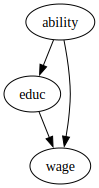

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import graphviz as gr
from linearmodels.iv import IV2SLS

%matplotlib inline

pd.set_option("display.max_columns", 5)
style.use("fivethirtyeight")

g = gr.Digraph()

g.edge("ability", "educ")
g.edge("ability", "wage")
g.edge("educ", "wage")
g

In [17]:
data = pd.read_csv("./data/ak91.csv")
data.head()

group_data = (data
              .groupby(["year_of_birth", "quarter_of_birth"])
              [["log_wage", "years_of_schooling"]]
              .mean()
              .reset_index()
              .assign(time_of_birth = lambda d: d["year_of_birth"] + (d["quarter_of_birth"])/4))

plt.figure(figsize=(15,6))
plt.plot(group_data["time_of_birth"], group_data["years_of_schooling"], zorder=-1)
for q in range(1, 5):
    x = group_data.query(f"quarter_of_birth=={q}")["time_of_birth"]
    y = group_data.query(f"quarter_of_birth=={q}")["years_of_schooling"]
    plt.scatter(x, y, marker="s", s=200, c=f"C{q}")
    plt.scatter(x, y, marker=f"${q}$", s=100, c=f"white")

plt.title("Years of Education by Quarter of Birth (first stage)")
plt.xlabel("Year of Birth")
plt.ylabel("Years of Schooling");

factor_data = data.assign(**{f"q{int(q)}": (data["quarter_of_birth"] == q).astype(int)
                             for q in data["quarter_of_birth"].unique()})

factor_data.head()

first_stage = smf.ols("years_of_schooling ~ C(year_of_birth) + C(state_of_birth) + q4", data=factor_data).fit()

print("q4 parameter estimate:, ", first_stage.params["q4"])
print("q4 p-value:, ", first_stage.pvalues["q4"])

plt.figure(figsize=(15,6))
plt.plot(group_data["time_of_birth"], group_data["log_wage"], zorder=-1)
for q in range(1, 5):
    x = group_data.query(f"quarter_of_birth=={q}")["time_of_birth"]
    y = group_data.query(f"quarter_of_birth=={q}")["log_wage"]
    plt.scatter(x, y, marker="s", s=200, c=f"C{q}")
    plt.scatter(x, y, marker=f"${q}$", s=100, c=f"white")

plt.title("Average Weekly Wage by Quarter of Birth (reduced form)")
plt.xlabel("Year of Birth")
plt.ylabel("Log Weekly Earnings");

reduced_form = smf.ols("log_wage ~ C(year_of_birth) + C(state_of_birth) + q4", data=factor_data).fit()

print("q4 parameter estimate:, ", reduced_form.params["q4"])
print("q4 p-value:, ", reduced_form.pvalues["q4"])

reduced_form.params["q4"] / first_stage.params["q4"] #0.08530286492085315 #This means that we should expect each additional year of school to increase wages by 8%.

#ALTERNATIVELY, WE COULD DO IT BY HAND
iv_by_hand = smf.ols("log_wage ~ C(year_of_birth) + C(state_of_birth) + years_of_schooling_fitted",
                     data=factor_data.assign(years_of_schooling_fitted=first_stage.fittedvalues)).fit()

iv_by_hand.params["years_of_schooling_fitted"] #0.0853028649208674 #As you can see, the parameters are exactly the same. #In practice, however, we don’t do IV by hand.


#Using linearmodels!
def parse(model, exog="years_of_schooling"):
    param = model.params[exog]
    se = model.std_errors[exog]
    p_val = model.pvalues[exog]
    print(f"Parameter: {param}")
    print(f"SE: {se}")
    print(f"95 CI: {(-1.96*se,1.96*se) + param}")
    print(f"P-value: {p_val}")
    
formula = 'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q4]'
iv2sls = IV2SLS.from_formula(formula, factor_data).fit()
parse(iv2sls)

#Using multiple instruments
formula = 'log_wage ~ 1 + C(year_of_birth) + C(state_of_birth) + [years_of_schooling ~ q1+q2+q3]'
iv_many_zs = IV2SLS.from_formula(formula, factor_data).fit()
parse(iv_many_zs) #With all 3 dummies, the estimated return on education is now 0.1, which means that we should expect a 10% average increase on earnings for every additional year of education.

formula = "log_wage ~ years_of_schooling + C(state_of_birth) + C(year_of_birth) + C(quarter_of_birth)"
ols = IV2SLS.from_formula(formula, data=data).fit()
parse(ols) #The return on education is estimated to be lower with OLS than with 2SLS. #notice the confidence intervals. 2SLS has a much wider CI than the OLS estimate.

q4 parameter estimate:,  0.10085809272784482
q4 p-value:,  5.464829416657389e-15
q4 parameter estimate:,  0.008603484260145622
q4 p-value:,  0.0014949127183541374
Parameter: 0.0853028649580665
SE: 0.02554081280862408
95 CI: [0.03524287 0.13536286]
P-value: 0.0008381914596313766
Parameter: 0.10769370488924324
SE: 0.01955714900869993
95 CI: [0.06936169 0.14602572]
P-value: 3.657974678716869e-08
Parameter: 0.06732572817659133
SE: 0.00038839984390487577
95 CI: [0.06656446 0.06808699]
P-value: 0.0


IV: estimate ATE indirectly.
If impact of treatment on the outcome strong, then 2nd stage strong -> but problem if first-stage instrument weak (small correlation)

In [18]:

np.random.seed(12)
n = 10000
X = np.random.normal(0, 2, n) # observable variable
U = np.random.normal(0, 2, n) # unobservable (omitted) variable
T = np.random.normal(1 + 0.5*U, 5, n) # treatment
Y = np.random.normal(2 + X - 0.5*U + 2*T, 5, n) # outcome

stddevs = np.linspace(0.1, 100, 50)
Zs = {f"Z_{z}": np.random.normal(T, s, n) for z, s in enumerate(stddevs)} # instruments with decreasing \mathrm{Cov}(Z, T)

sim_data = pd.DataFrame(dict(U=U, T=T, Y=Y)).assign(**Zs)

sim_data.head()

corr = (sim_data.corr()["T"]
        [lambda d: d.index.str.startswith("Z")])

corr.head()

se = []
ate = []
for z in range(len(Zs)):
    formula = f'Y ~ 1 + X + [T ~ Z_{z}]'
    iv = IV2SLS.from_formula(formula, sim_data).fit()
    se.append(iv.std_errors["T"])
    ate.append(iv.params["T"])


plot_data = pd.DataFrame(dict(se=se, ate=ate, corr=corr)).sort_values(by="corr")

plt.scatter(plot_data["corr"], plot_data["se"])
plt.xlabel("Corr(Z, T)")
plt.ylabel("IV Standard Error");
plt.title("Variance of the IV Estimates by 1st Stage Strength");

plt.scatter(plot_data["corr"], plot_data["ate"])
plt.fill_between(plot_data["corr"],
                 plot_data["ate"]+1.96*plot_data["se"],
                 plot_data["ate"]-1.96*plot_data["se"], alpha=.5)
plt.xlabel("Corr(Z, T)")
plt.ylabel("$\hat{ATE}$");
plt.title("IV ATE Estimates by 1st Stage Strength");

Estimates vary wildly when the $cov(T,Z)$ is weak. SE increases when cov low.

Another thing to notice is that 2SLS is biased! Even with high correlation, the parameter estimate still does not reach the true ATE of 2.0. Actually, 2.0 is not even in the 95% CI! 2SLS is only consistent, which means that it approaches the true parameter value if the sample size is big enough. However, we can’t know how big is big enough. We can only stick to some rules of thumb to understand how this bias behaves:

2SLS is biased towards OLS. This means that if OLS has a negative/positive bias, 2SLS will also have it. The advantage of 2SLS is that it is at least consistent, where OLS is not, in the case of omitted variables. In the example above, our unobserved U impacts negatively the outcome but its positively correlated with the treatment, which will result in a negative bias. That is why we are seeing the ATE estimate below the true value (negative bias).

The bias will increase with the number of instruments we add. If we add too many instruments, 2SLS becomes more and more like OLS.

Besides knowing how this bias behaves, a final piece of advice is to avoid some common mistakes when doing IV:

1. Doing IV by hand. As we’ve seen, IV by hand will result in wrong standard errors, even if the parameter estimates are right. The SE won’t be completely off. Still, why do it if you can use software and get the right SE?

2. Using anything other than OLS on the 1st stage. Lots of Data Scientist encounter IV and think they can do better. For example, they see a dummy treatment and think about replacing the 1st stage by a logistic regression, after all, they are predicting a dummy variable, right?. The problem is that this is plain wrong. The consistency of IV relies on a property that only OLS can give, which is the orthogonality of the residuals, so anything different than OLS on the 1st stage will yield something biased. (OBS: there are some modern techniques that use Machine Learning for IV, but their results have been, at best, questionable).

Chapter 9:
Boost user engagement: measured by in app purchase. Come up with a push you can use to engage your users. With that push, you move on to design a randomised trial. You select 10000 random customers and, for each of them, you assign the push with 50% probability. However, when you execute the test, you notice that some customers who were assigned to receive the push are not receiving it. It is because they probably have an older phone that doesn’t support the kind of push the marketing team designed.

We want 
$$ATE = E[Y|Push\_Assigned = 1] - E[Y|Push\_Assigned = 0]$$

The causal effect of treatment assignment is biased towards zero because non compliance shrinks the detectable impact.

$$Potential Outcome = \begin{cases} Y_i(1,1), \text{ if } T_i = 1, Z_i = 1 \\ Y_i(1,0), \text{ if } T_i = 1, Z_i = 0 \\ Y_i(0,1), \text{ if } T_i = 0, Z_i = 1 \\ Y_i(0,0), \text{ if } T_i = 0, Z_i = 0 \end{cases}$$

$Z$ is assignment "doctor prescribes drug", $T$ is treatment "patient actually takes it".

$$Potential Treatment = \begin{cases} T_0 \text{ if }Z_i = 0 \\ T_1 \text{ if }Z_i = 1 \end{cases}$$

$$Z \to T \to Y$$

IV Assumptions:
1. Independence: Instrument Z is randomly assigned, $T_{0i}, T_{1i} \perp Z_i$ and $Y_i(T_{1i}, 1), Y_i(T_{0i},0)\perp Z_i$
2. Exclusion: $Y_i(1,1) = Y_i(1,0) = Y_{i1}$ and $Y_{i}(0,0) = Y_i(0,1) = Y_{i0}$
3. Instrument affects treatment: $E[T_{i1}] \neq E[T_{i0}]$ doctor prescribing drug actually affects whether the patient takes or not
4. Monotonicity: $T_{i1} > T_{i0}$ treatment level higher if assigned then not.



$$ATE = \frac{E[Y|Z = 1] - E[Y| Z = 0]}{E[T|Z=1] - E[T|Z=0]} = \frac{\text{Effect of assignment}}{\text{Effect of treatment}}$$

$$ATE = E[(Y_{i1}-Y_{i0})|T_{i1}>T_{i0}]$$

Because:
$$E[Y_i|Z_i = 1] = E[Y_{i0} + T_{i1}(Y_{i1}-Y_{i0})|Z=1]  \stackrel{\text{Indep}}{=} E[Y_{i0} + T_{i1}(Y_{i1}-Y_{i0})]$$

$$E[Y_i|Z_i = 1] - E[Y_i|Z_i = 0] \stackrel{\text{By above}}{=} E[(Y_{i1}-Y_{i0})(T_{i1}-T_{i0})]$$
$$E[(Y_{i1}-Y_{i0})(T_{i1}-T_{i0})] = E[(Y_{i1}-Y_{i0})|T_{i1} > T_{i0}]P(T_{i1} > T_{i0}) $$
$$E[T|Z = 1] - E[T|Z = 0] \stackrel{\text{By def}}{=} E[T_{i1} - T_{i0}] \stackrel{\text{T is 0 or 1}}{=} P(T_{i1} > T_{i0})$$

Compliers: $T_{i1} > T_{i0}$
Never Takers $T_{i1} = T_{i0} = 0$
Always Takers $T_{i1} = T_{i0} = 1$

In [19]:
data = pd.read_csv("./data/app_engagement_push.csv")
    
data.head()

ols = IV2SLS.from_formula("in_app_purchase ~ 1 + push_assigned + push_delivered", data).fit()
ols.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,69.292,0.3624,191.22,0.0000,68.581,70.002
push_assigned,-17.441,0.5702,-30.590,0.0000,-18.559,-16.324
push_delivered,27.600,0.6124,45.069,0.0000,26.399,28.800


In [20]:
reduced_form = IV2SLS.from_formula("in_app_purchase ~ 1 + push_assigned", data).fit()
reduced_form.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,69.292,0.3624,191.22,0.0000,68.581,70.002
push_assigned,2.3636,0.5209,4.5376,0.0000,1.3427,3.3845


In [21]:
iv = IV2SLS.from_formula("in_app_purchase ~ 1 + [push_delivered ~ push_assigned]", data).fit()
iv.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,69.292,0.3624,191.22,0.0000,68.581,70.002
push_delivered,3.2938,0.7165,4.5974,0.0000,1.8896,4.6981


Chapter 10

6 men, 4 women. Y = days hospitalised. T = drug. On men, $\beta_{Y \sim T} = -3$, on women, $\beta_{Y \sim T} = -2$. Men are more affected by the illness and stay longer at the hospital and get more of the drug. 1/6 do not get the drug. Women are more resistant to the illness and stay less at the hospital. 50% of the women get the drug.


In [22]:
drug_example = pd.DataFrame(dict(
    sex= ["M","M","M","M","M","M", "W","W","W","W"],
    drug=[1,1,1,1,1,0,  1,0,1,0],
    days=[5,5,5,5,5,8,  2,4,2,4]
))
drug_example.query("drug==1")["days"].mean() - drug_example.query("drug==0")["days"].mean()


np.float64(-1.1904761904761898)

In [ ]:
ATE SHOULD BE = -2.6

This estimate is done by
1. partitioning the data into confounder cells, in this case, men and women
2. estimating the effect on each cell
3.  combining the estimate with a weighted average, where the weight is the sample size of the cell or covariate group.

If we had exactly the same number of men and women in the data, the ATE estimate would be right in the middle of the ATE of the 2 groups, -2.5. Since there are more men than women in our dataset, the ATE estimate is a little bit closer to the men’s ATE. This is called a non-parametric estimate, since it places no assumption on how the data was generated.

If we control for sex using regression, we will add the assumption of linearity. Regression will also partition the data into men and women and estimate the effect on both of these groups. 

However, when it comes to combining the effect on each group, it does not weigh them just by the sample size. Instead, regression uses weights that are also proportional to the variance of the treatment in that group. In our case, the variance of the treatment in men is smaller than in women, since only one man is in the control group. To be exact, the variance of T for men is $0.139 = 1/6 \times (1 - 1/6)$ and for women is $0.25 = 2/4 * (1- 2/4) $. So regression will give a higher weight to women in our example and the ATE will be a bit closer to the women’s ATE of -2.

In [23]:
smf.ols('days ~ drug + C(sex)', data=drug_example).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,7.5455,0.188,40.093,0.000,7.100,7.990
C(sex)[T.W],-3.3182,0.176,-18.849,0.000,-3.734,-2.902
drug,-2.4545,0.188,-13.042,0.000,-2.900,-2.010


So we’ve seen that regression has its idiosyncrasies. It is linear, parametric, likes high variance features… This can be good or bad, depending on the context. Because of this, it’s important to be aware of other techniques we can use to control for confounders. Not only are they an extra tool in your causal tool belt, but understanding different ways to deal with confounding expands our understanding of the problem. For this reason, I present you now the Subclassification Estimator!

We need to estimate the effect of the training program within small groups of individuals that are roughly the same in motivation level and any other confounders we may have -> looking for confounders. Need to compare treatment VS control where $X$ is the same. 

If conditional independence, then $(Y_{0}, Y_1) \perp T|X$, then 

$$ATE = \int (E[Y|X, T = 1] - E[Y|X, T = 0])dP(x)$$
$$\hat{ATE} = \sum_{k = 1}^n (\bar{Y}_{k1} - \bar{Y}_{k0}) \frac{N_k}{N}$$

MATCHING ESTIMATOR

Since some sort of confounder $X$ makes it so that treated and untreated are not initially comparable, I can make them so by matching each treated unit with a similar untreated unit



In [26]:
trainee = pd.read_csv("./data/trainees.csv")
print(trainee.query("trainees==1"))
print(trainee.query("trainees==0"))

    unit  trainees  age  earnings
0      1         1   28     17700
1      2         1   34     10200
2      3         1   29     14400
3      4         1   25     20800
4      5         1   29      6100
5      6         1   23     28600
6      7         1   33     21900
7      8         1   27     28800
8      9         1   31     20300
9     10         1   26     28100
10    11         1   25      9400
11    12         1   27     14300
12    13         1   29     12500
13    14         1   24     19700
14    15         1   25     10100
15    16         1   43     10700
16    17         1   28     11500
17    18         1   27     10700
18    19         1   28     16300
    unit  trainees  age  earnings
19    20         0   43     20900
20    21         0   50     31000
21    22         0   30     21000
22    23         0   27      9300
23    24         0   54     41100
24    25         0   48     29800
25    26         0   39     42000
26    27         0   28      8800
27    28      

In [28]:
print(trainee.query("trainees==1")["earnings"].mean() - trainee.query("trainees==0")["earnings"].mean()) #-4297.49373433584
#Trainees receive much less but age is confounder

# make dataset where no one has the same age
unique_on_age = (trainee
                 .query("trainees==0")
                 .drop_duplicates("age"))

matches = (trainee
           .query("trainees==1")
           .merge(unique_on_age, on="age", how="left", suffixes=("_t_1", "_t_0"))
           .assign(t1_minuts_t0 = lambda d: d["earnings_t_1"] - d["earnings_t_0"]))

matches.head(7)

matches["t1_minuts_t0"].mean() #2457.8947368421054

-4297.49373433584


np.float64(2457.8947368421054)

$$\hat{ATE} = \frac{\sum_{i=1}^N (2T_i-1)(Y_i-Y_{jm}(i))}{N}$$

where $Y_{jm}(i) = $ sample of the other group most similar to $Y_i$. So $()$ is 1 if treated and -1 if untreated 

In [31]:
med = pd.read_csv("./data/medicine_impact_recovery.csv")
med.head()

np.float64(16.895799546498726)

In [35]:
med.query("medication==1")["recovery"].mean() - med.query("medication==0")["recovery"].mean() #Diff of means = 16.9 days to recover the treated. Strange

#CORRECT FOR BIAS
# scale features
X = ["severity", "age", "sex"]
y = "recovery"

med = med.assign(**{f: (med[f] - med[f].mean())/med[f].std() for f in X}) #STANDARDISE
med.head()

#Now, to the matching itself. We will use the K nearest neighbour algorithm from Sklearn. 

,sex,age,severity,medication,recovery
0,-0.996980,0.280787,1.459800,1,31
1,1.002979,0.865375,1.502164,1,49
2,1.002979,-0.338749,0.057796,0,38
3,1.002979,0.399465,-0.512557,0,35
4,-0.996980,-0.610473,-0.911125,0,15


For matching, we will need 2 of those. One, $mt0$, will store the untreated points and will find matches in the untreated when asked to do so. The other, $mt1$, will store the treated point and will find matches in the treated when asked to do so. After this fitting step, we can use these KNN models to make predictions, which will be our matches.

In [33]:
from sklearn.neighbors import KNeighborsRegressor

treated = med.query("medication==1")
untreated = med.query("medication==0")

mt0 = KNeighborsRegressor(n_neighbors=1).fit(untreated[X], untreated[y])
mt1 = KNeighborsRegressor(n_neighbors=1).fit(treated[X], treated[y])

predicted = pd.concat([
    # find matches for the treated looking at the untreated knn model
    treated.assign(match=mt0.predict(treated[X])),
    
    # find matches for the untreated looking at the treated knn model
    untreated.assign(match=mt1.predict(untreated[X]))
])

predicted.head()

,sex,age,...,recovery,match
0,-0.996980,0.280787,...,31,39.0
1,1.002979,0.865375,...,49,52.0
7,-0.996980,1.495134,...,38,46.0
10,1.002979,-0.106534,...,34,45.0
16,-0.996980,0.043034,...,30,39.0


In [36]:
np.mean((2*predicted["medication"] - 1)*(predicted["recovery"] - predicted["match"]))

np.float64(-0.9954)

Using matching, it goes from $+17$ days to $-1$ day. Can do better

$$\hat{ATET} = \frac{\sum Y_i - Y_j(i)}{N_1}$$
Where $N_1 = \#$ treated individuals and $Y_j(i) = $untreated match of treated $i$.

$\mu_0(x) = E[Y|X=x, T = 0]$ mean outcome for untreated given $X$. Counterfactual for an unit with $X = x$.
$$E[\sqrt{N_1}(\hat{ATET} - ATET)] = E[\sqrt{N_1}(\mu_0(X_i) - \mu_0(X_j(i)))]$$

Difference between $\hat{ATET} - ATET$ slowly converge to 0 but $N_1$ increases so it may not be 0.

Bias arises when the matching discrepancies are huge. Fortunately, we know how to correct it. Each observation contributes $(\mu_0(X_i) - \mu_0(X_j(i)))$ to the bias so all we need to do is subtract this quantity from each matching comparison in our estimator. To do so, we can replace $\mu_0(X_j(i))$  with some sort of estimate of this quantity $\hat{\mu}_0(X_j(i))$
, which can be obtained with models like linear regression. This updates the ATET estimator to the following equation

$$\hat{ATET} = \frac{\sum Y_i - Y_j(i) - (\hat{\mu}_0(X_i) - \hat{\mu}_0(X_{j(i)}) )}{N_1}$$

where $\hat{\mu}_0(X_i) = $estimative of $E[Y|X=x, T = 0]$, like a regression fitted only on the untreated sample.

In [37]:
from sklearn.linear_model import LinearRegression

# fit the linear regression model to estimate mu_0(x)
ols0 = LinearRegression().fit(untreated[X], untreated[y])
ols1 = LinearRegression().fit(treated[X], treated[y])

# find the units that match to the treated
treated_match_index = mt0.kneighbors(treated[X], n_neighbors=1)[1].ravel()

# find the units that match to the untreatd
untreated_match_index = mt1.kneighbors(untreated[X], n_neighbors=1)[1].ravel()

predicted = pd.concat([
    (treated
     # find the Y match on the other group
     .assign(match=mt0.predict(treated[X])) 
     
     # build the bias correction term
     .assign(bias_correct=ols0.predict(treated[X]) - ols0.predict(untreated.iloc[treated_match_index][X]))),
    (untreated
     .assign(match=mt1.predict(untreated[X]))
     .assign(bias_correct=ols1.predict(untreated[X]) - ols1.predict(treated.iloc[untreated_match_index][X])))
])

predicted.head()

,sex,age,...,match,bias_correct
0,-0.996980,0.280787,...,39.0,4.404034
1,1.002979,0.865375,...,52.0,12.915348
7,-0.996980,1.495134,...,46.0,1.871428
10,1.002979,-0.106534,...,45.0,-0.496970
16,-0.996980,0.043034,...,39.0,2.610159


First of all, this linear regression that we are fitting doesn’t extrapolate on the treatment dimension to get the treatment effect. Instead, its purpose is just to correct bias. Linear regression here is local, in the sense that it doesn’t try to see how the treated would be if it looked like the untreated. It does none of that extrapolation. This is left to the matching part. The meat of the estimator is still the matching component. The point I want to make here is that OLS is secondary to this estimator.

The second point is that matching is a non-parametric estimator. It doesn’t assume linearity or any kind of parametric model. As such, it is more flexible than linear regression and can work in situations where linear regression will not, namely, those where non linearity is very strong.

Does this mean that you should only use matching? Well, that’s a tough question. Alberto Abadie makes a case that yes, you should. It’s more flexible and, once you have the code, equally simple to run. I’m not entirely convinced by that. For example, Abadie spent a lot of time studying and developing the estimator (yes, he is one of the scientists that contributes to matching being what it is), so he obviously is personally invested in the method. Second, there is something about linear regression’s simplicity that you don’t see in matching. The partial derivative math of “holding everything else constant” is much easier to grasp with linear regression than with matching. But that’s just my preference. To be honest, there is no clear answer to this question. Anyway, back to our example.

With the bias correction formula, I get the following ATE estimation.

In [38]:
np.mean((2*predicted["medication"] - 1)*((predicted["recovery"] - predicted["match"])-predicted["bias_correct"])) # -7.36266090614141

np.float64(-7.362660906141414)

In [41]:
from causalinference import CausalModel

cm = CausalModel(
    Y=med["recovery"].values, 
    D=med["medication"].values, 
    X=med[["severity", "age", "sex"]].values
)

cm.est_via_matching(matches=1, bias_adj=True)

print(cm.estimates)


Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE     -7.709      0.609    -12.649      0.000     -8.903     -6.514
           ATC     -6.665      0.246    -27.047      0.000     -7.148     -6.182
           ATT     -9.679      1.693     -5.717      0.000    -12.997     -6.361



Finally, we can say with confidence that our medicine does indeed lower the time someone spends at the hospital. The ATE estimate is just a little bit lower than mine, due to the difference in tie breaking of matches of knn sklearn implementation and the causalinference python package.

Before we close this topic, I just wanted to address the cause of bias in matching a little bit more. We saw that matching is biased when the unit and its match are not so similar. But what causes them to be so different?



#The Curse of Dimensionality

It is easy to find people that match on a few characteristics, but if we add more characteristics, it becomes harder to find matches. The more features we have, the higher will be the distance between units and their matches.

This is not something that hurts only the matching estimator. It ties back to the subclassification estimator we saw earlier. Early on, in that contrived medicine example where with man and woman, it was quite easy to build the subclassification estimator. That was because we only had 2 cells: man and woman. But what would happen if we had more? Let’s say we have 2 continuous features like age and income and we manage to discretise them into 5 buckets each. This will give us 25 cells, or . And what if we had 10 covariates with 3 buckets each? Doesn’t seem like a lot right? Well, this would give us 59049 cells. This is a phenomena pervasive in all data science, which is called the The Curse of Dimensionality!!!

In the context of the subclassification estimator, the curse of dimensionality means that it will suffer if we have lots of features. Lots of features imply multiple cells in X. If there are multiple cells, some of them will have very few data. Some of them might even have only treated or only control, so it won’t be possible to estimate the ATE there, which would break our estimator. In the matching context, this means that the feature space will be very sparse and units will be very far from each other. This will increase the distance between matches and cause bias problems.

As for linear regression, it actually handles this problem quite well. What it does is project all the features X into a single one, the Y dimension. It then makes treatment and control comparison on that projection. So, in some way, linear regression performs some sort of dimensionality reduction to estimate the ATE. It’s quite elegant.

Most causal models also have some way to deal with the curse of dimensionality. 